In [2]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


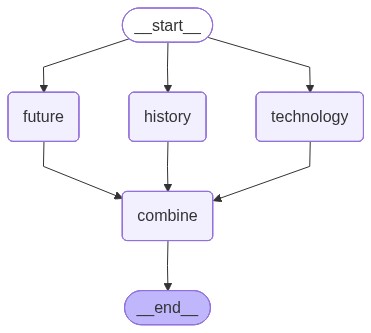

In [4]:
from typing_extensions import TypedDict
from typing import List, Dict, Any

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
    topic: str
    results: Dict[str, str]

llm = ChatPerplexity(model="sonar-pro")

def research_history(state: State) -> State:
    topic = state["topic"]
    prompt = f"Give one short historical fact about {topic}."
    response = llm.invoke([HumanMessage(content=prompt)])
    results = dict(state.get("results", {}))
    results["history"] = response.content
    return {"topic": topic, "results": results}

def research_technology(state: State) -> State:
    topic = state["topic"]
    prompt = f"Explain one way technology is related to {topic}."
    response = llm.invoke([HumanMessage(content=prompt)])
    results = dict(state.get("results", {}))
    results["technology"] = response.content
    return {"topic": topic, "results": results}

def research_future(state: State) -> State:
    topic = state["topic"]
    prompt = f"Describe one possible future development related to {topic}."
    response = llm.invoke([HumanMessage(content=prompt)])
    results = dict(state.get("results", {}))
    results["future"] = response.content
    return {"topic": topic, "results": results}

def combine_results(state: State) -> State:
    return state

builder = StateGraph(State)
builder.add_node("history", research_history)
builder.add_node("technology", research_technology)
builder.add_node("future", research_future)
builder.add_node("combine", combine_results)

builder.add_edge(START, "history")
builder.add_edge(START, "technology")
builder.add_edge(START, "future")

builder.add_edge("history", "combine")
builder.add_edge("technology", "combine")
builder.add_edge("future", "combine")

builder.add_edge("combine", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
second_state = {"topic": "artificial intelligence in education", "results": {}}

output2 = graph.invoke(second_state)
print("Parallel research results for topic:", output2["topic"])
for key, value in output2["results"].items():
    print(f"\n[{key.upper()}]")
    print(value)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

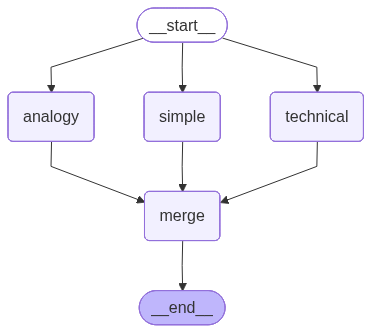

In [7]:
from typing_extensions import TypedDict
from typing import Dict

class ExplainState(TypedDict):
    concept: str
    explanations: Dict[str, str]

def explain_simple(state: ExplainState) -> ExplainState:
    concept = state["concept"]
    prompt = f"Explain {concept} in one sentence for a complete beginner."
    response = llm.invoke([HumanMessage(content=prompt)])
    explanations = dict(state.get("explanations", {}))
    explanations["simple"] = response.content
    return {"concept": concept, "explanations": explanations}

def explain_technical(state: ExplainState) -> ExplainState:
    concept = state["concept"]
    prompt = f"Explain {concept} in a slightly technical way, in two sentences."
    response = llm.invoke([HumanMessage(content=prompt)])
    explanations = dict(state.get("explanations", {}))
    explanations["technical"] = response.content
    return {"concept": concept, "explanations": explanations}

def explain_analogy(state: ExplainState) -> ExplainState:
    concept = state["concept"]
    prompt = f"Explain {concept} using a real-world analogy in one or two sentences."
    response = llm.invoke([HumanMessage(content=prompt)])
    explanations = dict(state.get("explanations", {}))
    explanations["analogy"] = response.content
    return {"concept": concept, "explanations": explanations}

def merge_explanations(state: ExplainState) -> ExplainState:
    return state

builder2 = StateGraph(ExplainState)
builder2.add_node("simple", explain_simple)
builder2.add_node("technical", explain_technical)
builder2.add_node("analogy", explain_analogy)
builder2.add_node("merge", merge_explanations)

builder2.add_edge(START, "simple")
builder2.add_edge(START, "technical")
builder2.add_edge(START, "analogy")

builder2.add_edge("simple", "merge")
builder2.add_edge("technical", "merge")
builder2.add_edge("analogy", "merge")

builder2.add_edge("merge", END)

graph_explain = builder2.compile(checkpointer=memory)

display(Image(graph_explain.get_graph().draw_mermaid_png()))

In [8]:
concept_state = {"concept": "cloud computing", "explanations": {}}

result = graph_explain.invoke(concept_state)

print("Different explanations for:", result["concept"])
for style, text in result["explanations"].items():
    print(f"\n[{style.upper()}]")
    print(text)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [9]:
from langgraph.graph import MessagesState

class MessagesExplainState(MessagesState):
    mode: str

def parallel_assistant(state: MessagesExplainState) -> MessagesExplainState:
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": messages + [response], "mode": state.get("mode", "default")}

builder3 = StateGraph(MessagesExplainState)
builder3.add_node("branch_a", parallel_assistant)
builder3.add_node("branch_b", parallel_assistant)
builder3.add_node("branch_c", parallel_assistant)

builder3.set_entry_point("branch_a")
builder3.add_edge("branch_a", "branch_b")
builder3.add_edge("branch_b", "branch_c")
builder3.add_edge("branch_c", END)

graph_stream = builder3.compile(checkpointer=memory)

from langchain_core.messages import HumanMessage

initial_messages = {
    "messages": [HumanMessage(content="Give me three short tips to stay focused while studying.")],
    "mode": "tips",
}

for event in graph_stream.stream(initial_messages, stream_mode="values"):
    print("Step:")
    for m in event["messages"]:
        print(f"{m.type}: {m.content}")
    print("-" * 40)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id